In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define data directory
data_dir = Path('slice_0')

# Load all CSV files
action_df = pd.read_csv(data_dir / 'action.csv')
allocation_df = pd.read_csv(data_dir / 'allocation.csv')
energy_df = pd.read_csv(data_dir / 'energy.csv', header=None, names=['energy'])
latency_df = pd.read_csv(data_dir / 'latency.csv', header=None, names=['latency'])
rejection_df = pd.read_csv(data_dir / 'rejection.csv')
reward_df = pd.read_csv(data_dir / 'reward.csv', header=None, names=['reward'])

print("Data loaded successfully!")
print(f"Number of episodes: {len(reward_df)}")
print(f"Action columns: {list(action_df.columns)}")
print(f"Allocation columns: {list(allocation_df.columns)}")
print(f"Rejection columns: {list(rejection_df.columns)}")

Data loaded successfully!
Number of episodes: 10001
Action columns: ['mec_0', 'mec_1', 'mec_2', 'mec_3', 'mec_4', 'link_0', 'link_1', 'link_2', 'link_3', 'link_4', 'link_5', 'link_6', 'link_7', 'link_8', 'link_9']
Allocation columns: ['mec_0', 'mec_1', 'mec_2', 'mec_3', 'mec_4', 'link_0', 'link_1', 'link_2', 'link_3', 'link_4', 'link_5', 'link_6', 'link_7', 'link_8', 'link_9']
Rejection columns: ['mec_0', 'mec_1', 'mec_2', 'mec_3', 'mec_4', 'link_0', 'link_1', 'link_2', 'link_3', 'link_4', 'link_5', 'link_6', 'link_7', 'link_8', 'link_9']


In [2]:
reward_df = reward_df[1:].reset_index(drop=True)
latency_df = latency_df[1:].reset_index(drop=True)
energy_df = energy_df[1:].reset_index(drop=True)

In [3]:
reward_df = reward_df.astype(float)
latency_df = latency_df.astype(float)
energy_df = energy_df.astype(float)

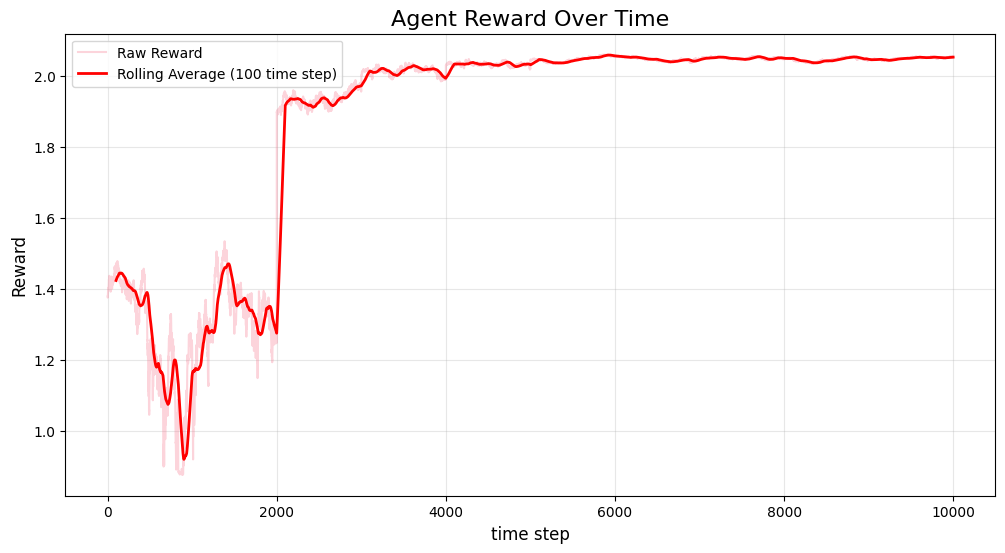

Mean reward: 1.8806
Std reward: 0.3053
Min reward: 0.8759
Max reward: 2.0611
Rolling average (last 100): 2.0543


In [4]:
# Cell 2: Plot reward over time
plt.figure(figsize=(12, 6))
plt.plot(reward_df.index, reward_df['reward'], alpha=0.3, label='Raw Reward')
reward_rolling = reward_df['reward'].rolling(window=100).mean()
plt.plot(reward_df.index, reward_rolling, linewidth=2, label='Rolling Average (100 time step)', color='red')
plt.title('Agent Reward Over Time', fontsize=16)
plt.xlabel('time step', fontsize=12)
plt.ylabel('Reward', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate and display reward statistics
print(f"Mean reward: {reward_df['reward'].mean():.4f}")
print(f"Std reward: {reward_df['reward'].std():.4f}")
print(f"Min reward: {reward_df['reward'].min():.4f}")
print(f"Max reward: {reward_df['reward'].max():.4f}")
print(f"Rolling average (last 100): {reward_rolling.iloc[-1]:.4f}")

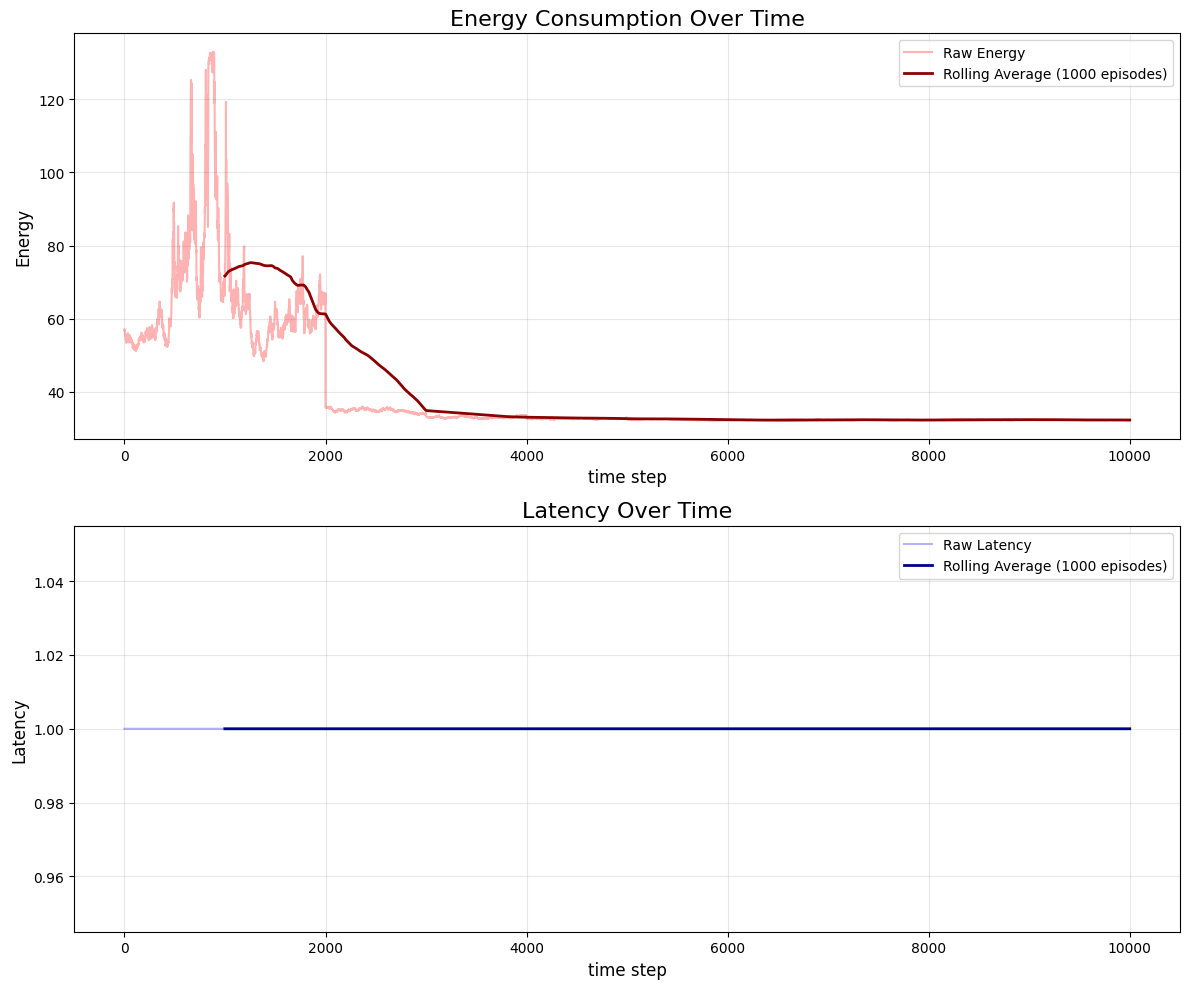

Energy Statistics:
Mean: 39.47, Std: 15.53
Min: 32.03, Max: 133.02
Rolling average (last 1000): 32.24

Latency Statistics:
Mean: 1.00, Std: 0.00
Min: 1.00, Max: 1.00
Rolling average (last 1000): 1.00


In [5]:
# Cell 3: Plot energy and latency over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Energy plot
ax1.plot(energy_df.index, energy_df['energy'], alpha=0.3, color='red', label='Raw Energy')
energy_rolling = energy_df['energy'].rolling(window=1000).mean()
ax1.plot(energy_df.index, energy_rolling, linewidth=2, label='Rolling Average (1000 episodes)', color='darkred')
ax1.set_title('Energy Consumption Over Time', fontsize=16)
ax1.set_xlabel('time step', fontsize=12)
ax1.set_ylabel('Energy', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Latency plot
ax2.plot(latency_df.index, latency_df['latency'], alpha=0.3, color='blue', label='Raw Latency')
latency_rolling = latency_df['latency'].rolling(window=1000).mean()
ax2.plot(latency_df.index, latency_rolling, linewidth=2, label='Rolling Average (1000 episodes)', color='darkblue')
ax2.set_title('Latency Over Time', fontsize=16)
ax2.set_xlabel('time step', fontsize=12)
ax2.set_ylabel('Latency', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("Energy Statistics:")
print(f"Mean: {energy_df['energy'].mean():.2f}, Std: {energy_df['energy'].std():.2f}")
print(f"Min: {energy_df['energy'].min():.2f}, Max: {energy_df['energy'].max():.2f}")
print(f"Rolling average (last 1000): {energy_rolling.iloc[-1]:.2f}")

print("\nLatency Statistics:")
print(f"Mean: {latency_df['latency'].mean():.2f}, Std: {latency_df['latency'].std():.2f}")
print(f"Min: {latency_df['latency'].min():.2f}, Max: {latency_df['latency'].max():.2f}")
print(f"Rolling average (last 1000): {latency_rolling.iloc[-1]:.2f}")

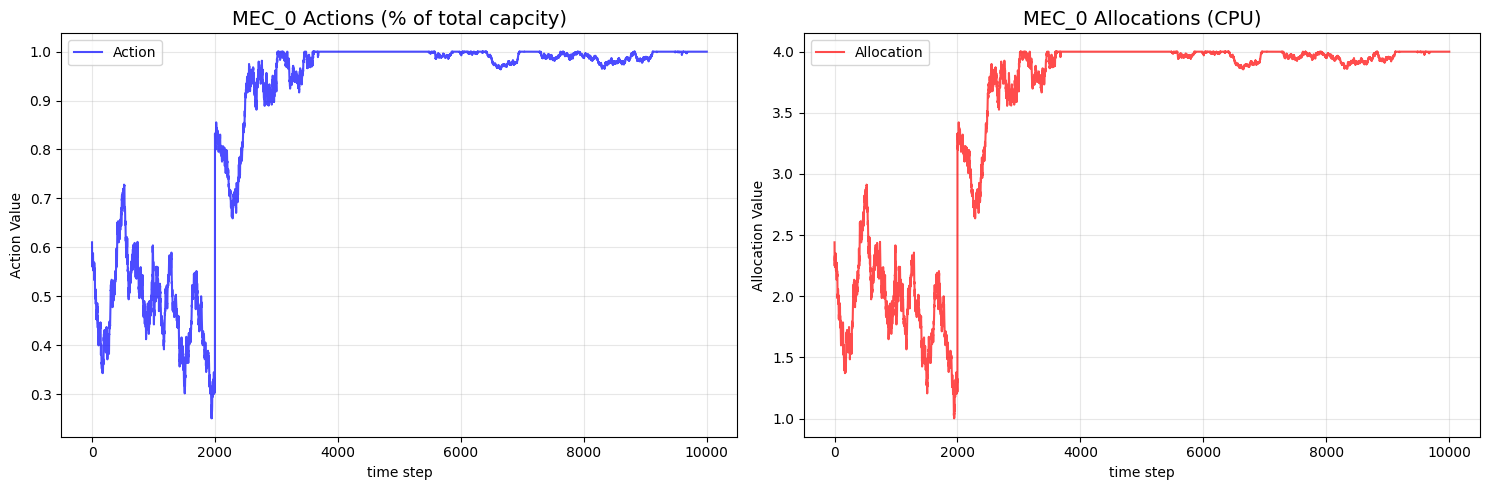

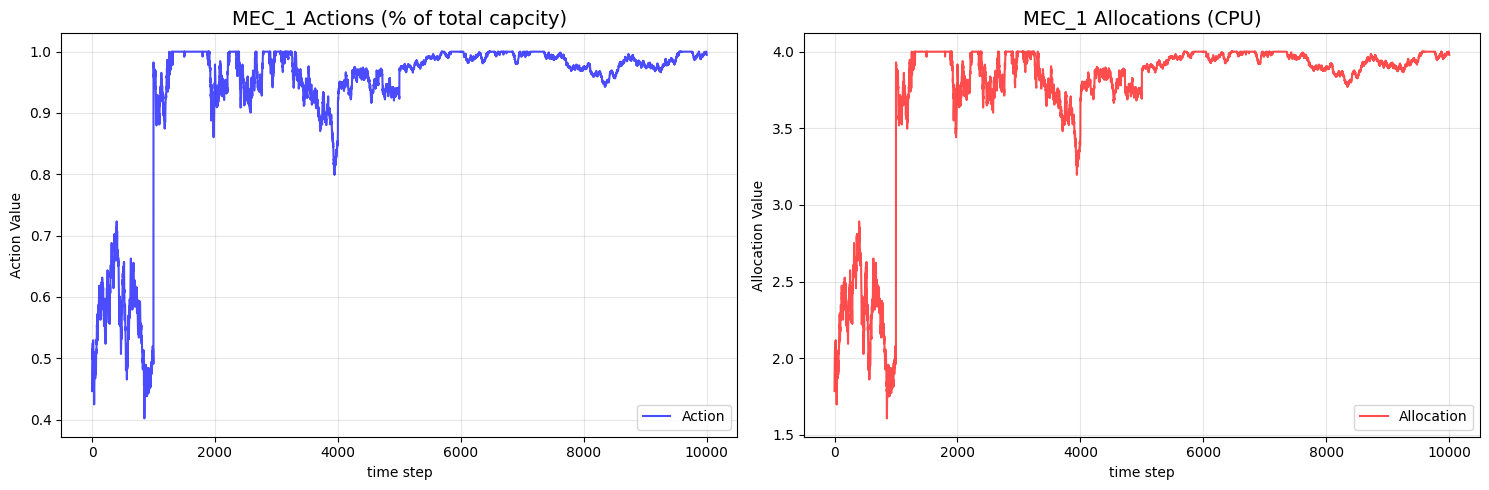

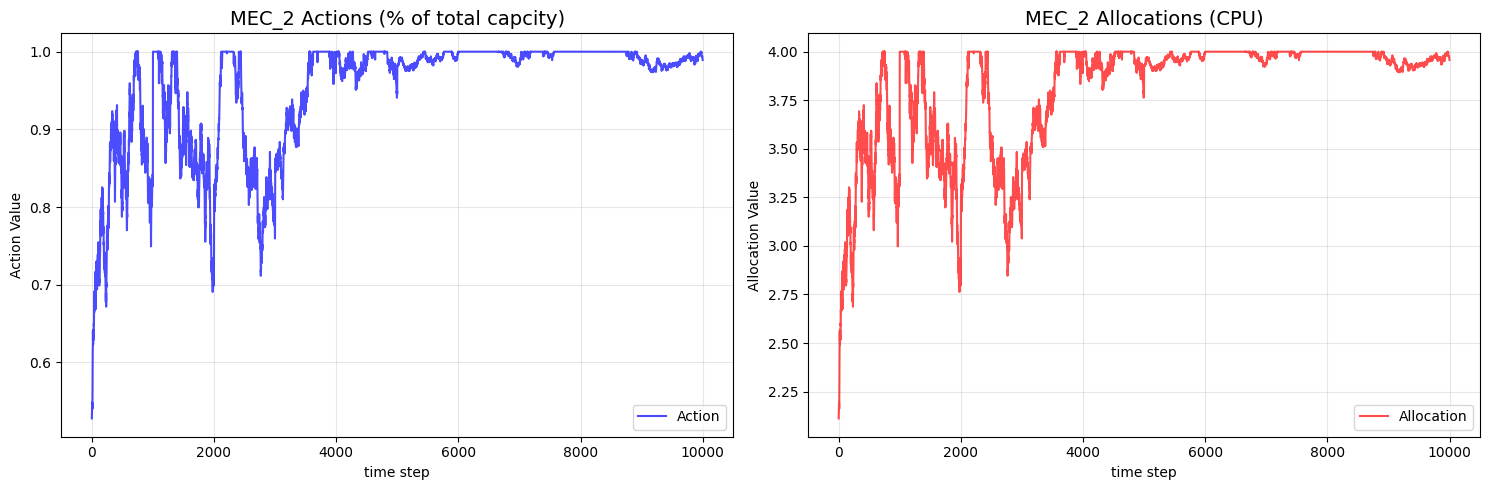

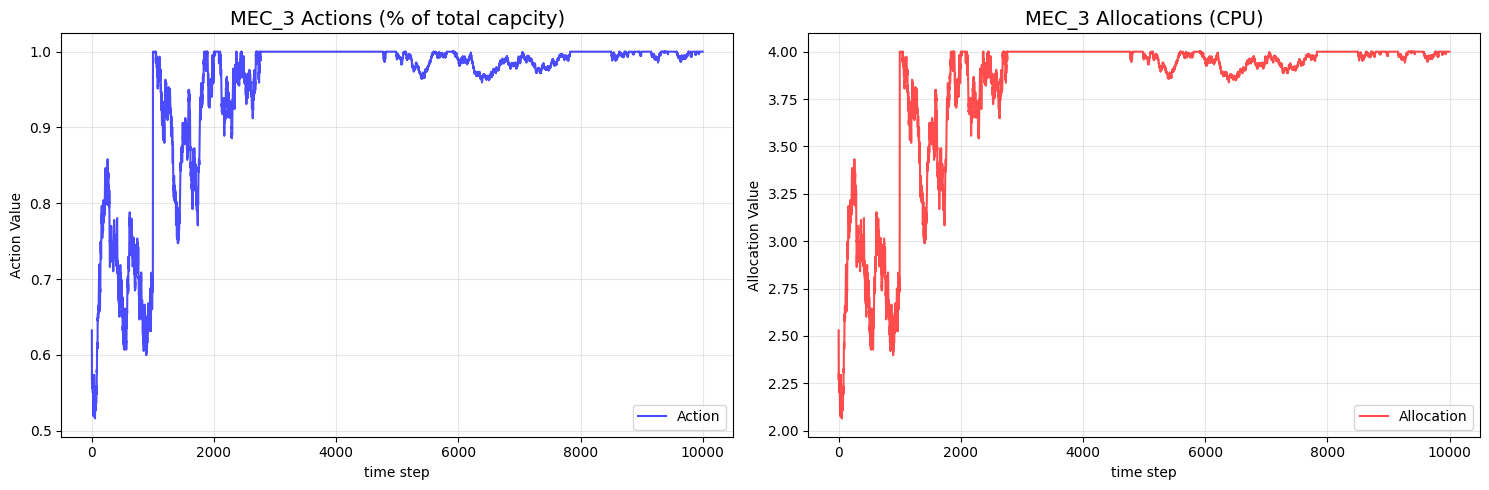

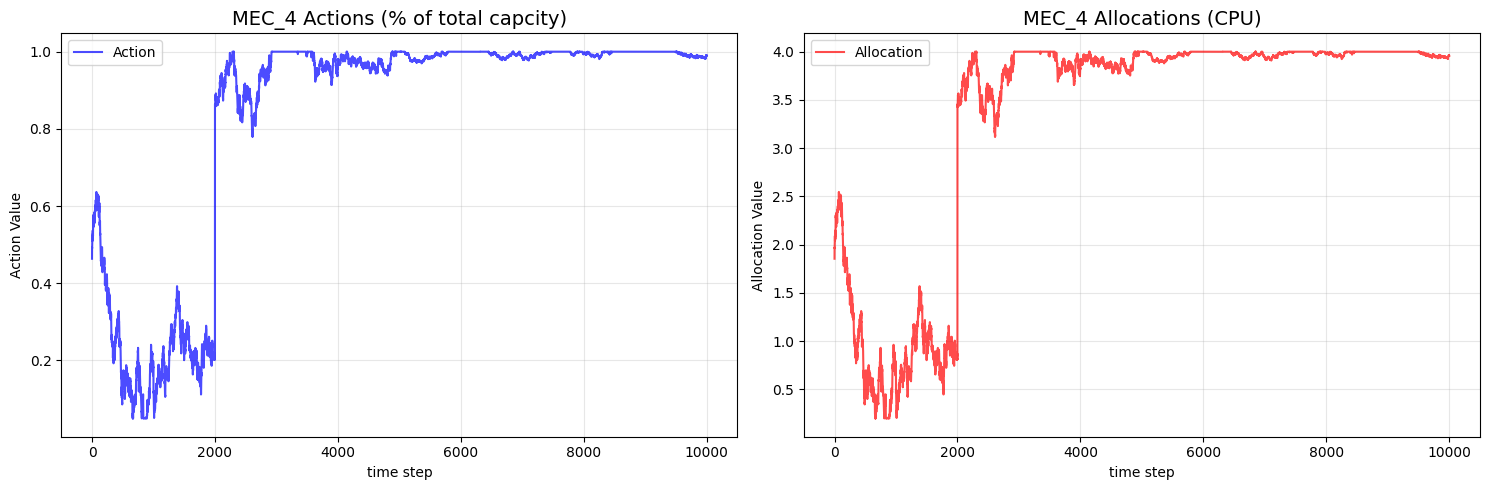

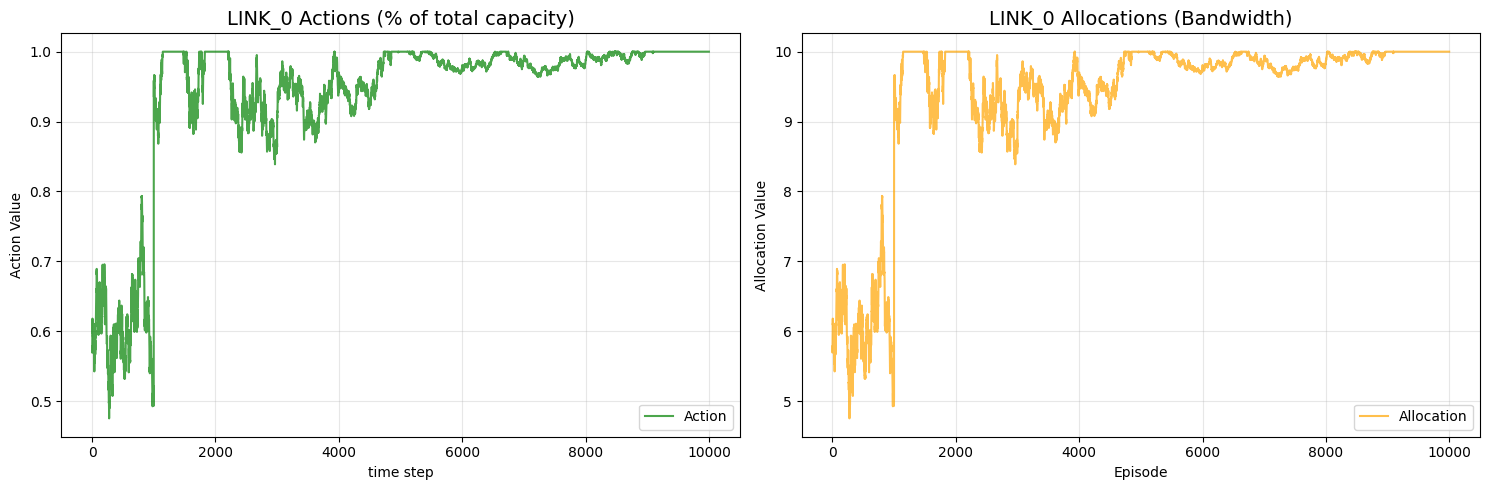

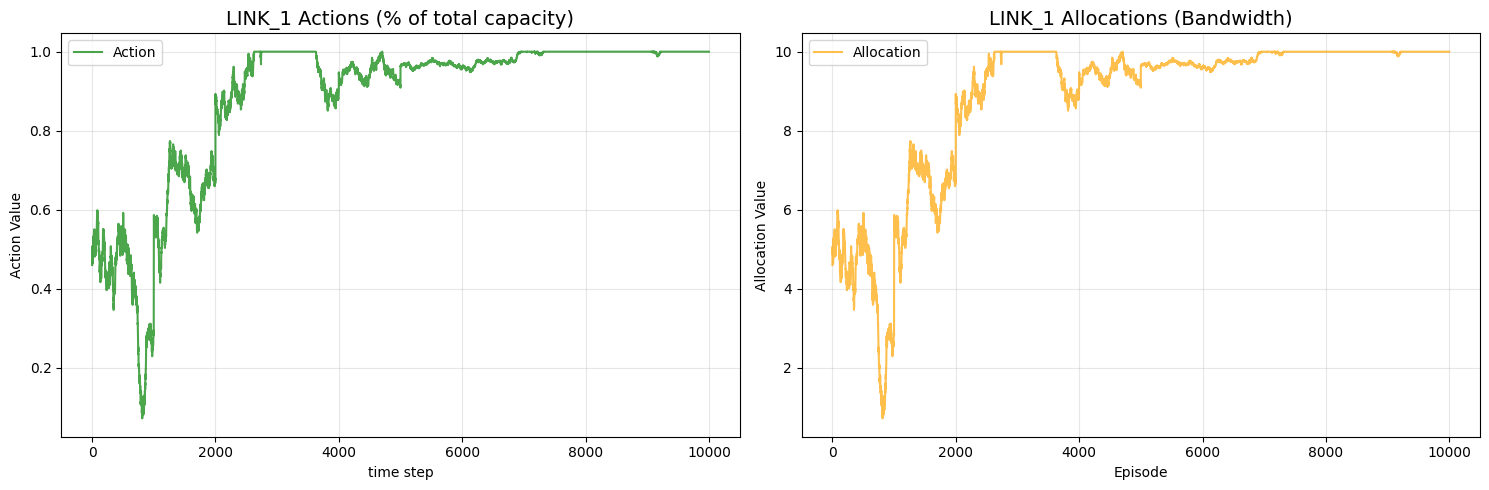

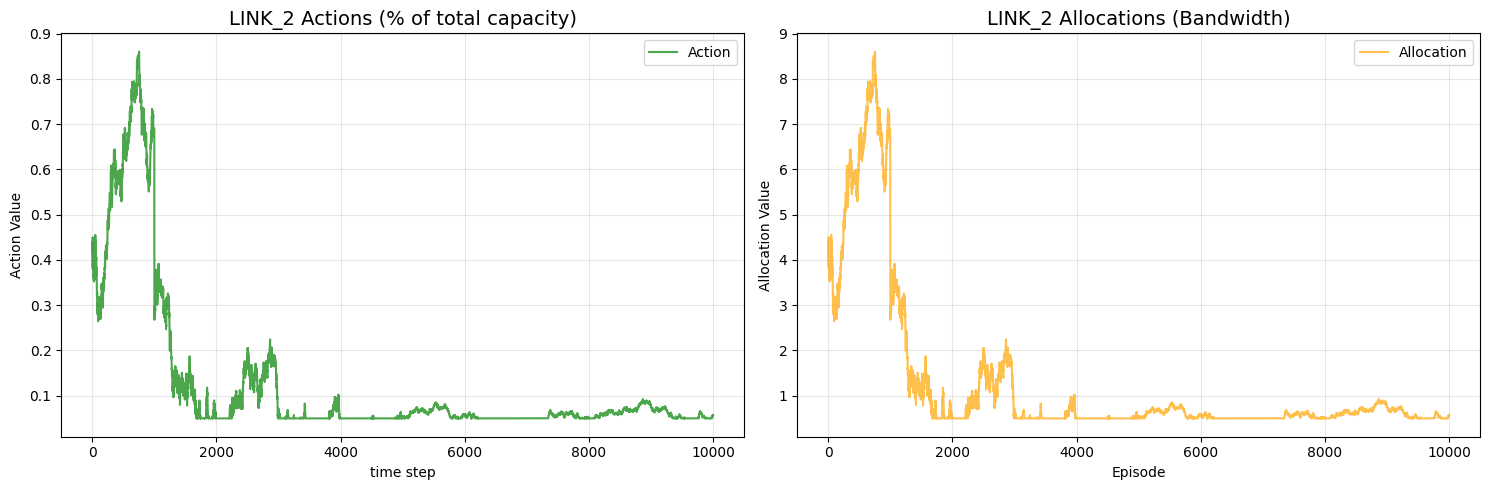

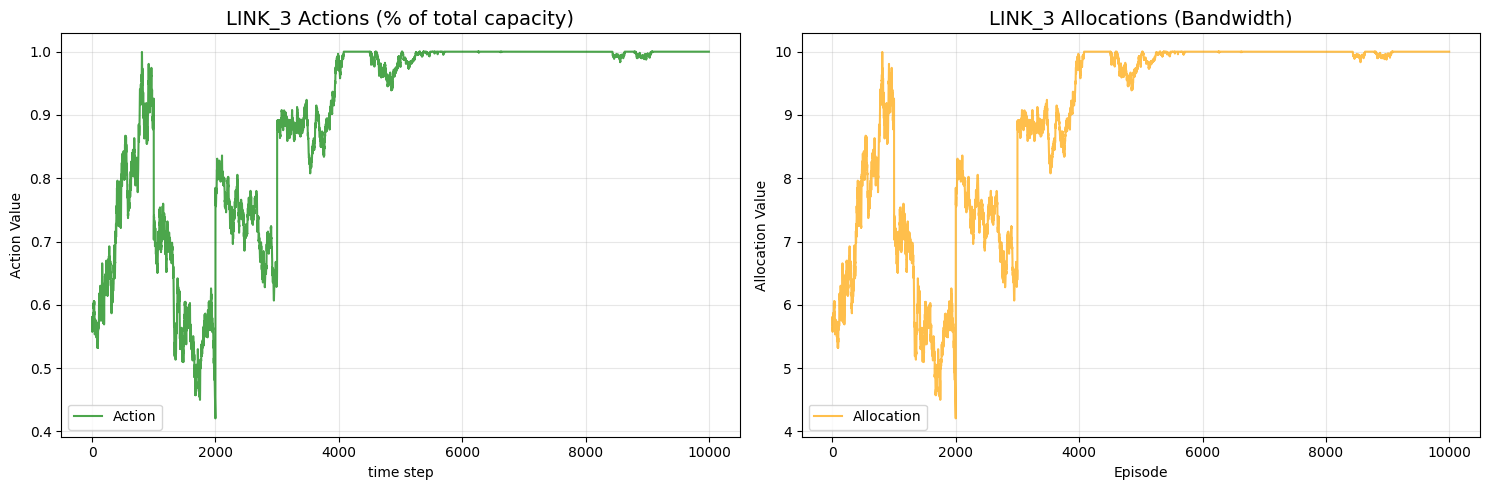

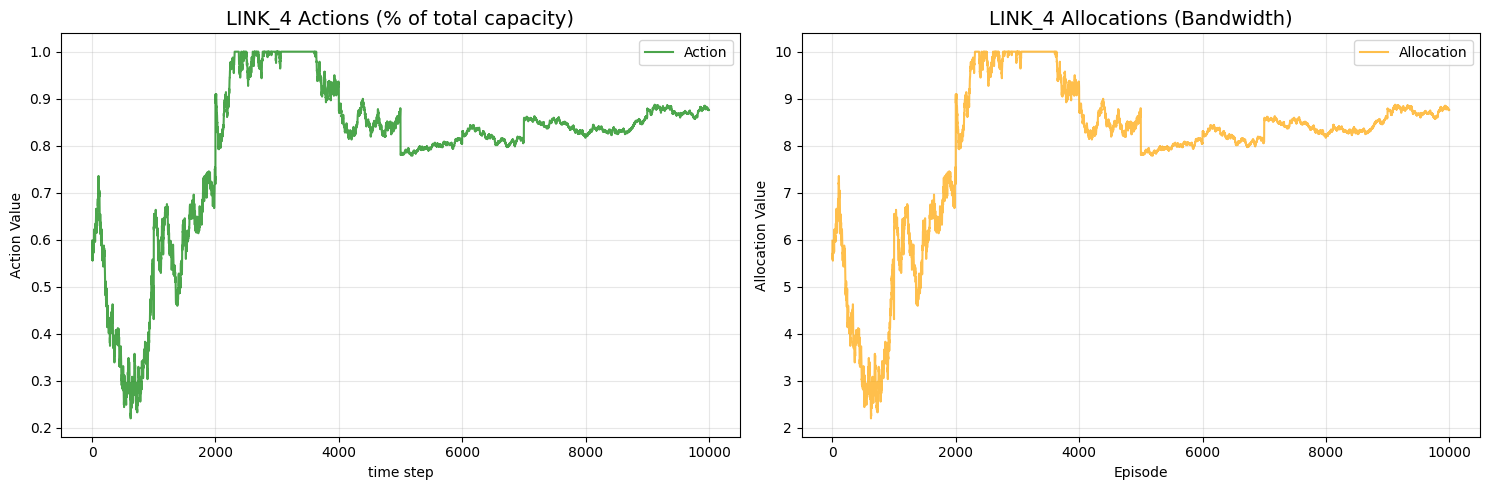

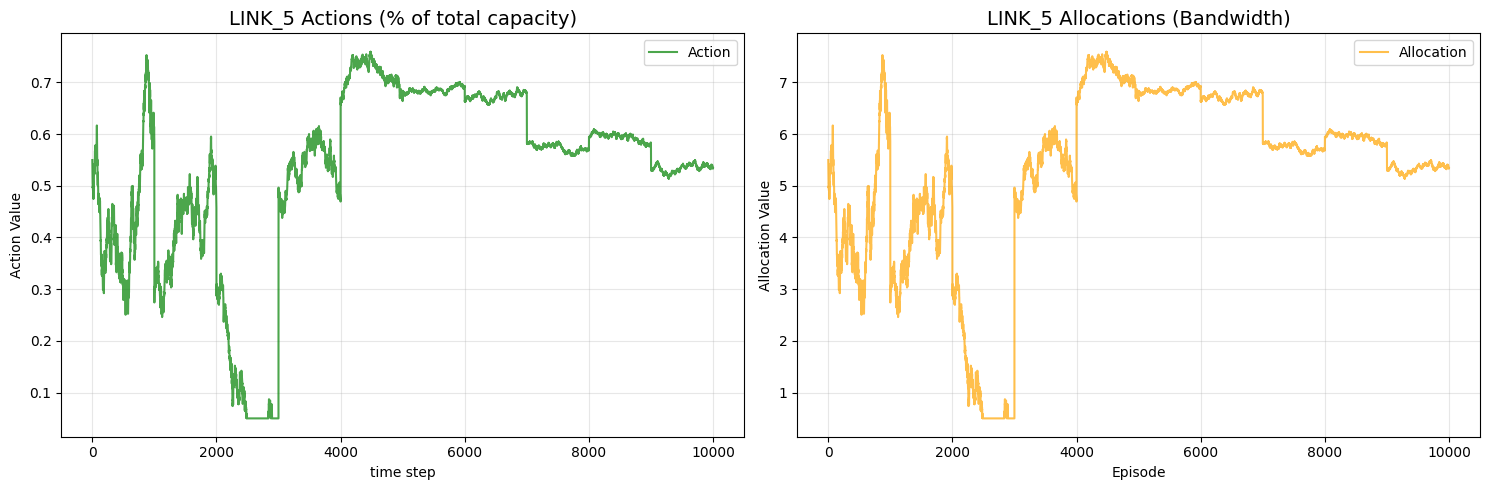

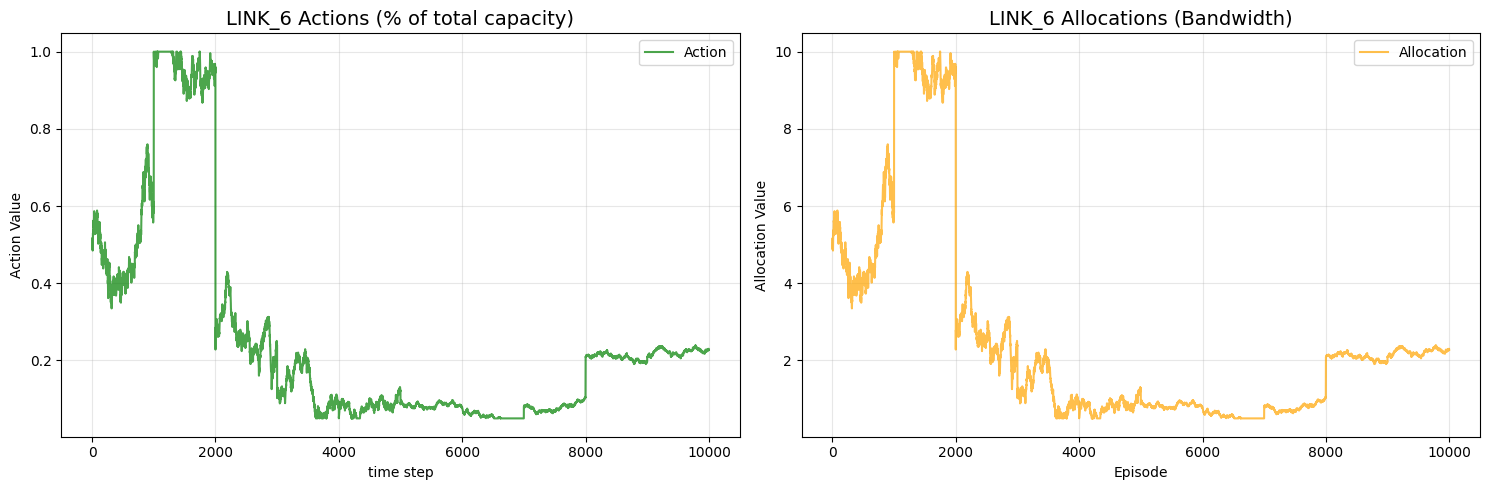

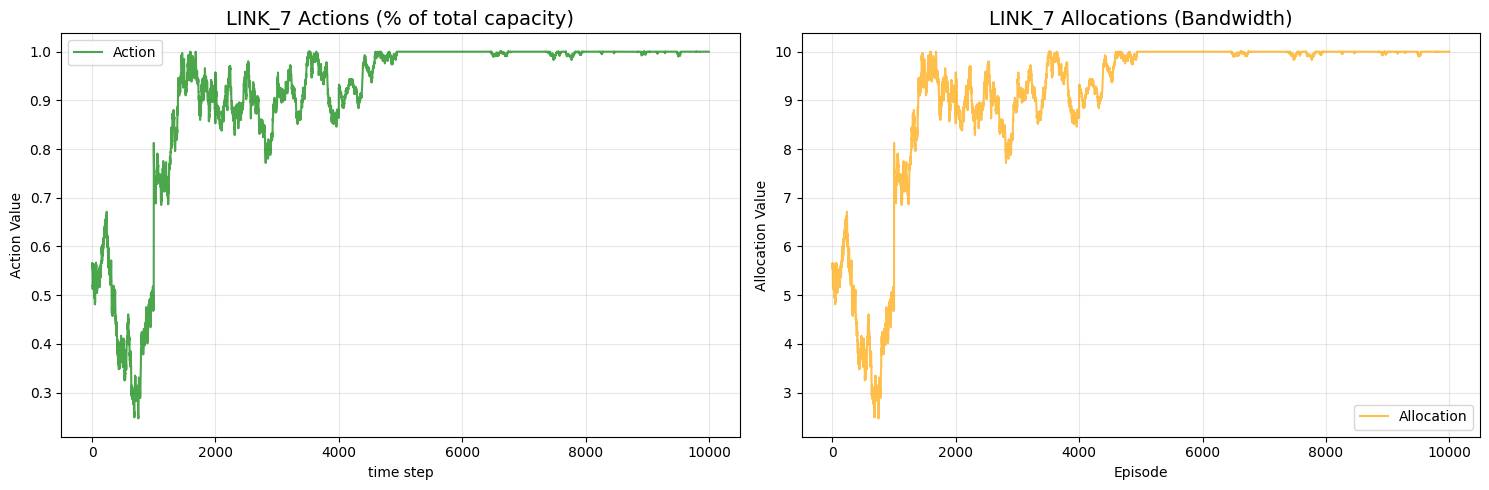

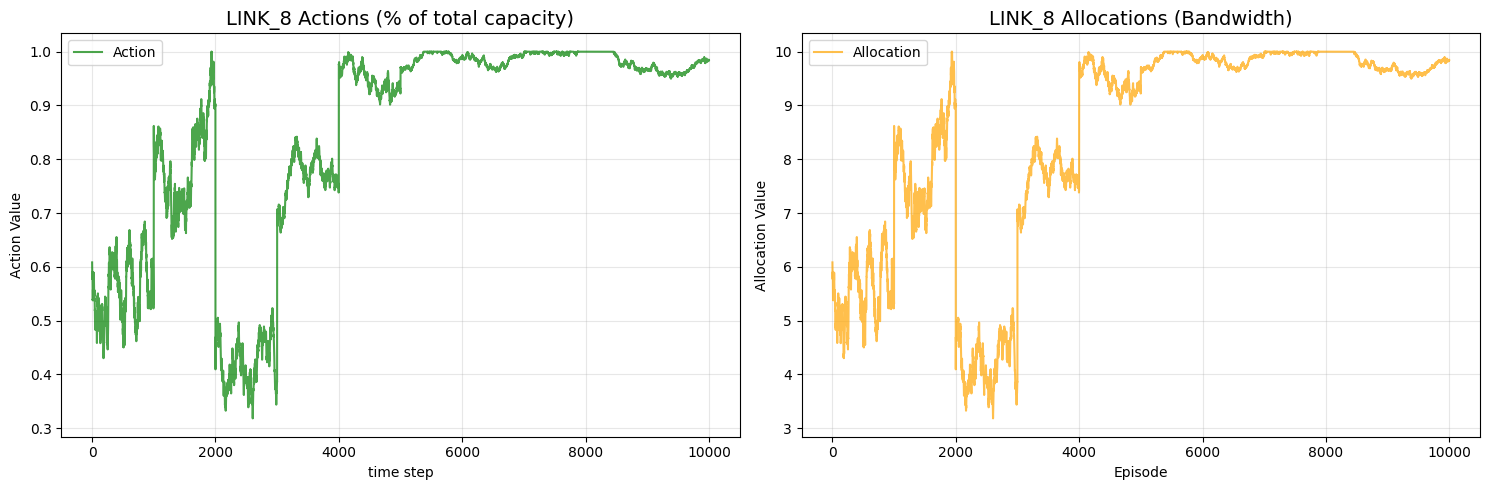

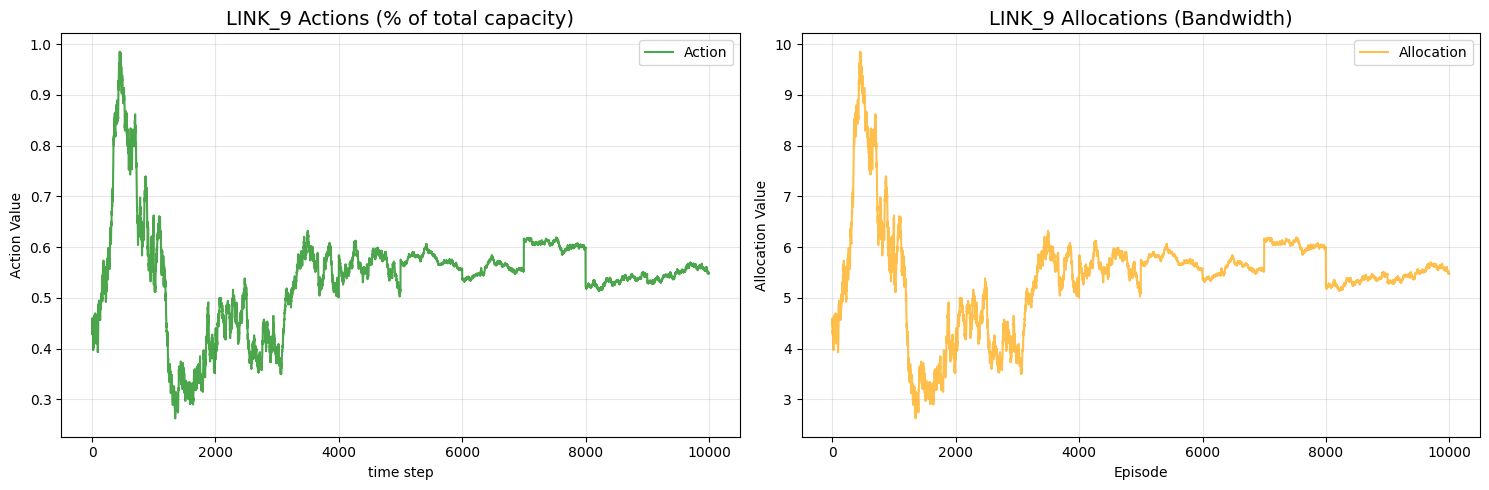

In [6]:
# Cell 4: Individual plots for each MEC and Link resource
sample_size = min(500000, len(action_df))  # Show more episodes for better trend visibility

# Plot MEC resources
mec_cols = [col for col in action_df.columns if col.startswith('mec_')]
for i, mec in enumerate(mec_cols):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Actions
    ax1.plot(action_df.index[:sample_size], action_df[mec][:sample_size], alpha=0.7, color='blue', label='Action')
    ax1.set_title(f'{mec.upper()} Actions (% of total capcity)', fontsize=14)
    ax1.set_xlabel('time step')
    ax1.set_ylabel('Action Value')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Allocations
    ax2.plot(allocation_df.index[:sample_size], allocation_df[mec][:sample_size], alpha=0.7, color='red', label='Allocation')
    ax2.set_title(f'{mec.upper()} Allocations (CPU)', fontsize=14)
    ax2.set_xlabel('time step')
    ax2.set_ylabel('Allocation Value')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Plot Link resources
link_cols = [col for col in action_df.columns if col.startswith('link_')]
for i, link in enumerate(link_cols):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Actions
    ax1.plot(action_df.index[:sample_size], action_df[link][:sample_size], alpha=0.7, color='green', label='Action')
    ax1.set_title(f'{link.upper()} Actions (% of total capacity)', fontsize=14)
    ax1.set_xlabel('time step')
    ax1.set_ylabel('Action Value')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Allocations
    ax2.plot(allocation_df.index[:sample_size], allocation_df[link][:sample_size], alpha=0.7, color='orange', label='Allocation')
    ax2.set_title(f'{link.upper()} Allocations (Bandwidth)', fontsize=14)
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Allocation Value')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    